# Keras Transformer forecast for VIX log returns

This notebook mirrors the data loading, leakage-safe feature engineering, walk-forward splitting, and evaluation workflow from `rnn.ipynb`, but replaces the recurrent GRU with a compact Keras Transformer encoder for sequence forecasting.


In [37]:
import random

import numpy as np
import pandas as pd
try:
    import yahooquery as yq
except ImportError:
    yq = None

try:
    import yfinance as yf
except ImportError:
    yf = None

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## Load and Prep Data

These cells intentionally match the source data and base preprocessing in `arima.ipynb`: Reddit daily sentiment, daily GPR indexes, Yahoo VIX prices, an inner merge through `dropna`, and close-to-close VIX log returns. The S&P 500 data is downloaded from the same Yahoo source family and shifted before modeling so the Transformer only sees market information available before the VIX close being predicted.

In [38]:
sentiment_df = pd.read_csv("../data/daily-sentiment-comments.csv").rename(columns={"created_date": "date"})
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df.sample(5, random_state=RANDOM_SEED)

,date,final_score,score
149,2012-09-27,-0.303370,2.6
1972,2018-01-16,-0.295691,4.0
238,2013-02-13,-0.622145,2.0
1052,2015-07-10,0.313151,4.2
308,2013-05-22,-0.156370,2.2


In [39]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df.head()

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405


In [40]:
def flatten_yahoo_columns(frame):
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str(col[0]).lower().replace(" ", "") for col in out.columns]
    else:
        out.columns = [str(col).lower().replace(" ", "") for col in out.columns]
    return out


def load_yahoo_adjclose(symbol, start="2012-01-01", end="2026-01-01"):
    if yq is not None:
        hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
        hist["date"] = pd.to_datetime(hist["date"])
        return hist[["date", "adjclose"]].copy()

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download market history.")

    hist = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    hist["date"] = pd.to_datetime(hist["date"])
    return hist[["date", "adjclose"]].copy()


vix = load_yahoo_adjclose("^VIX")
sp500 = load_yahoo_adjclose("^GSPC").rename(columns={"adjclose": "sp500_adjclose"})

vix.head()

,date,adjclose
0,2012-01-03,22.969999
1,2012-01-04,22.219999
2,2012-01-05,21.480000
3,2012-01-06,20.629999
4,2012-01-09,21.070000


In [41]:
# Merge VIX, S&P 500, sentiment, and GPR. The VIX/sentiment/GPR path mirrors arima.ipynb;
# S&P 500 is added as an additional market input and shifted below before modeling.
df = (
    vix
    .merge(sp500, on="date", how="left")
    .merge(sentiment_df, on="date", how="left")
    .merge(gpr_df, on="date", how="left")
    .dropna()
)
df = df.sort_values("date").reset_index(drop=True)

# Add close-to-close VIX and S&P 500 log returns.
df["log_return"] = np.log(df["adjclose"]).diff()
df["sp500_log_return"] = np.log(df["sp500_adjclose"]).diff()
df = df.dropna()

# These columns are contemporaneous in the raw merge, so match arima.ipynb
# by shifting them back one row before modeling.
for col in ["GPRD_THREAT", "GPRD_ACT", "GPRD", "final_score"]:
    df[f"{col}_lag1"] = df[col].shift(1)

# Add explicit lagged market levels and returns. The lookback window already
# contains prior rows, but these make the exact short-horizon lags visible to
# the model at each sequence step.
MARKET_LAGS = [1, 2, 5, 10]
for lag in MARKET_LAGS:
    df[f"vix_log_return_lag{lag}"] = df["log_return"].shift(lag)
    df[f"vix_adjclose_lag{lag}"] = df["adjclose"].shift(lag)
    df[f"sp500_log_return_lag{lag}"] = df["sp500_log_return"].shift(lag)
    df[f"sp500_adjclose_lag{lag}"] = df["sp500_adjclose"].shift(lag)

df = df.dropna().reset_index(drop=True)
df.head()

,date,adjclose,sp500_adjclose,final_score,score,GPRD,GPRD_ACT,GPRD_THREAT,log_return,sp500_log_return,...,sp500_log_return_lag2,sp500_adjclose_lag2,vix_log_return_lag5,vix_adjclose_lag5,sp500_log_return_lag5,sp500_adjclose_lag5,vix_log_return_lag10,vix_adjclose_lag10,sp500_log_return_lag10,sp500_adjclose_lag10
0,2012-05-03,17.559999,1391.569946,0.101250,3.0,101.763199,62.968941,128.387894,0.039494,-0.007688,...,0.005642,1405.819946,-0.035091,16.240000,0.006658,1399.979980,-0.081126,18.459999,0.015996,1390.780029
1,2012-05-04,19.160000,1369.099976,0.471239,3.6,62.240311,48.260120,74.756889,0.087201,-0.016279,...,-0.002500,1402.310059,0.004914,16.320000,0.002411,1403.359985,-0.005432,18.360001,-0.010016,1376.920044
2,2012-05-07,18.940001,1369.579956,0.684462,2.2,60.385345,60.199474,50.212307,-0.011549,0.000351,...,-0.007688,1391.569946,0.049607,17.150000,-0.003891,1397.910034,0.032684,18.969999,-0.007275,1366.939941
3,2012-05-08,19.049999,1363.719971,-0.191538,3.8,84.524818,80.252037,80.325752,0.005791,-0.004288,...,-0.016279,1369.099976,-0.032595,16.600000,0.005642,1405.819946,-0.046947,18.100000,0.003673,1371.969971
4,2012-05-09,20.080000,1354.579956,-0.200860,2.2,54.602768,21.773876,72.646255,0.052657,-0.006725,...,0.000351,1369.579956,0.016727,16.879999,-0.002500,1402.310059,-0.073343,16.820000,0.013552,1390.689941


## Sequence Features

The Transformer predicts one trading day at a time. Each target uses a lookback window ending on that target date, but all target-history and market features are shifted one row so the model only sees information available before the close being predicted.


In [42]:
def build_rolling_features(series: pd.Series, prefix="") -> pd.DataFrame:
    # Same rolling windows used in arima.ipynb.
    out = pd.DataFrame(index=series.index)
    for window, label in [(21, "3w"), (42, "6w"), (365, "1y")]:
        out[f"{prefix}{label}_rolling_mean"] = series.rolling(window, min_periods=window).mean()
        out[f"{prefix}{label}_rolling_std"] = series.rolling(window, min_periods=window).std()
    return out

TARGET_COL = "log_return"
EXOG_COLS = [
    "GPRD_THREAT_lag1",
    "GPRD_ACT_lag1",
    "GPRD_lag1",
    "final_score_lag1",
]
MARKET_LAG_COLS = []
for lag in MARKET_LAGS:
    MARKET_LAG_COLS.extend([
        f"vix_log_return_lag{lag}",
        f"vix_adjclose_lag{lag}",
        f"sp500_log_return_lag{lag}",
        f"sp500_adjclose_lag{lag}",
    ])

model_df = df.copy()
vix_rolling = build_rolling_features(model_df[TARGET_COL].shift(1), prefix="vix_")
sp500_rolling = build_rolling_features(model_df["sp500_log_return"].shift(1), prefix="sp500_")
model_df = pd.concat([model_df, vix_rolling, sp500_rolling], axis=1).dropna().reset_index(drop=True)

ROLLING_COLS = list(vix_rolling.columns) + list(sp500_rolling.columns)
FEATURE_COLS = EXOG_COLS + MARKET_LAG_COLS + ROLLING_COLS

print(f"Rows available for Transformer: {len(model_df):,}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")
print(f"Feature count: {len(FEATURE_COLS)}")
model_df[["date", TARGET_COL, *FEATURE_COLS]].head()

Rows available for Transformer: 2,522
Date range: 2013-12-20 to 2023-12-29
Feature count: 32


,date,log_return,GPRD_THREAT_lag1,GPRD_ACT_lag1,GPRD_lag1,final_score_lag1,vix_log_return_lag1,vix_adjclose_lag1,sp500_log_return_lag1,sp500_adjclose_lag1,...,vix_6w_rolling_mean,vix_6w_rolling_std,vix_1y_rolling_mean,vix_1y_rolling_std,sp500_3w_rolling_mean,sp500_3w_rolling_std,sp500_6w_rolling_mean,sp500_6w_rolling_std,sp500_1y_rolling_mean,sp500_1y_rolling_std
0,2013-12-20,-0.025771,61.584431,80.545639,67.328606,0.054754,0.025046,14.15,-0.000580,1809.599976,...,0.001727,0.046144,-0.000483,0.067630,0.000575,0.006113,0.000870,0.005865,0.000699,0.008011
1,2013-12-23,-0.055922,147.142303,70.563492,106.172050,0.069863,-0.025771,13.79,0.004807,1818.319946,...,0.000808,0.046302,-0.000662,0.067611,0.000978,0.006100,0.000848,0.005848,0.000733,0.008002
2,2013-12-24,-0.043894,43.861526,42.068424,47.473106,0.212401,-0.055922,13.04,0.005304,1827.989990,...,-0.000684,0.047109,-0.001054,0.067515,0.000845,0.005966,0.001087,0.005819,0.000792,0.007956
3,2013-12-26,-0.012092,75.580894,80.545639,75.744690,0.357267,-0.043894,12.48,0.002912,1833.319946,...,-0.001335,0.047521,-0.001143,0.067550,0.000748,0.005912,0.001079,0.005817,0.000799,0.007956
4,2013-12-27,0.010488,61.017490,135.857056,104.828094,-0.019090,-0.012092,12.33,0.004734,1842.020020,...,-0.001424,0.047538,-0.001192,0.067551,0.001033,0.005955,0.001088,0.005822,0.000824,0.007954


## Keras Dataset and Transformer Model


In [43]:
LOOKBACK_DAYS = 20
BATCH_SIZE = 32
MODEL_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_TRANSFORMER_BLOCKS = 2
DROPOUT = 0.1
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 75
PATIENCE = 10

N_SPLITS = 10
TEST_SIZE = 200
VALIDATION_SIZE = 200


In [44]:
def eligible_target_indices(indices, lookback_days):
    return [int(idx) for idx in indices if int(idx) >= lookback_days - 1]


def split_train_validation(train_target_indices, validation_size=VALIDATION_SIZE):
    train_target_indices = list(train_target_indices)
    if len(train_target_indices) <= validation_size + 1:
        validation_size = max(1, len(train_target_indices) // 5)
    return train_target_indices[:-validation_size], train_target_indices[-validation_size:]


def build_sequence_arrays(frame, target_indices, feature_cols, target_col, feature_scaler, target_scaler, lookback_days):
    raw_features = frame[feature_cols].astype(np.float32)
    raw_targets = frame[[target_col]].astype(np.float32)
    features = feature_scaler.transform(raw_features).astype(np.float32)
    targets_scaled = target_scaler.transform(raw_targets).reshape(-1).astype(np.float32)
    targets_raw = raw_targets.to_numpy(dtype=np.float32).reshape(-1)

    x, y, y_raw, kept_indices = [], [], [], []
    for target_idx in target_indices:
        target_idx = int(target_idx)
        start_idx = target_idx - lookback_days + 1
        if start_idx < 0:
            continue
        x.append(features[start_idx:target_idx + 1])
        y.append(targets_scaled[target_idx])
        y_raw.append(targets_raw[target_idx])
        kept_indices.append(target_idx)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(y_raw, dtype=np.float32),
        np.asarray(kept_indices, dtype=int),
    )


def make_arrays_for_fold(train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    train_target_indices = eligible_target_indices(train_idx, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_idx, LOOKBACK_DAYS)
    fit_target_indices, val_target_indices = split_train_validation(train_target_indices)

    scaler_fit_idx = train_idx[train_idx <= max(fit_target_indices)]
    feature_scaler = StandardScaler().fit(model_df.iloc[scaler_fit_idx][FEATURE_COLS])
    target_scaler = StandardScaler().fit(model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        model_df, fit_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    val_arrays = build_sequence_arrays(
        model_df, val_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    test_arrays = build_sequence_arrays(
        model_df, test_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    fold_indices = {
        "fit_target_indices": np.asarray(fit_target_indices, dtype=int),
        "val_target_indices": np.asarray(val_target_indices, dtype=int),
        "test_target_indices": np.asarray(test_target_indices, dtype=int),
        "scaler_fit_indices": np.asarray(scaler_fit_idx, dtype=int),
    }
    return train_arrays, val_arrays, test_arrays, target_scaler, fold_indices


class NumericTokenAndPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.value_projection = layers.Dense(model_dim)
        self.position_embedding = layers.Embedding(input_dim=sequence_length, output_dim=model_dim)

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        return self.value_projection(inputs) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "model_dim": self.model_dim})
        return config


def build_keras_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = NumericTokenAndPositionEmbedding(
        sequence_length=input_shape[0],
        model_dim=MODEL_DIM,
        name="token_position_embedding",
    )(inputs)

    for block_idx in range(NUM_TRANSFORMER_BLOCKS):
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=MODEL_DIM // NUM_HEADS,
            dropout=DROPOUT,
            name=f"self_attention_{block_idx + 1}",
        )(x, x)
        attention_output = layers.Dropout(DROPOUT)(attention_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn_output = layers.Dense(FF_DIM, activation="gelu")(x)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        ffn_output = layers.Dense(MODEL_DIM)(ffn_output)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D(name="sequence_pooling")(x)
    x = layers.Dense(MODEL_DIM // 2, activation="gelu")(x)
    x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    metrics = {
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }
    if np.any(actual != 0):
        metrics["directional_accuracy"] = float(np.mean(np.sign(actual) == np.sign(predicted)))
    else:
        metrics["directional_accuracy"] = np.nan
    return metrics


def evaluate_predictions(pred_scaled, y_raw, target_indices, target_scaler):
    pred_raw = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    out = pd.DataFrame({
        "target_index": target_indices,
        "date": model_df.iloc[target_indices]["date"].to_numpy(),
        "actual": y_raw,
        "predicted": pred_raw,
    })
    metrics = regression_metrics(out["actual"], out["predicted"])
    return metrics, out

## Walk-Forward Evaluation

This uses the same walk-forward `TimeSeriesSplit` setup as `rnn.ipynb`. The scaler is fit on each fold's training rows only; test sequences may use prior observed returns through yesterday, matching a one-day-ahead walk-forward forecast.

Epoch 1/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 1.2368 - val_loss: 1.6744
Epoch 2/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0725 - val_loss: 1.5214
Epoch 3/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9944 - val_loss: 1.6191
Epoch 4/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9836 - val_loss: 1.5892
Epoch 5/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9579 - val_loss: 1.5741
Epoch 6/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9357 - val_loss: 1.5429
Epoch 7/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9759 - val_loss: 1.5463
Epoch 8/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9203 - val_loss: 1.5411
Epoch 9/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9288 - val_loss: 1.6034
Epoch 10/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9280 - val_loss: 1.5773
Epoch 11/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8847 - val_loss: 1.5767
Epoch 12/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8

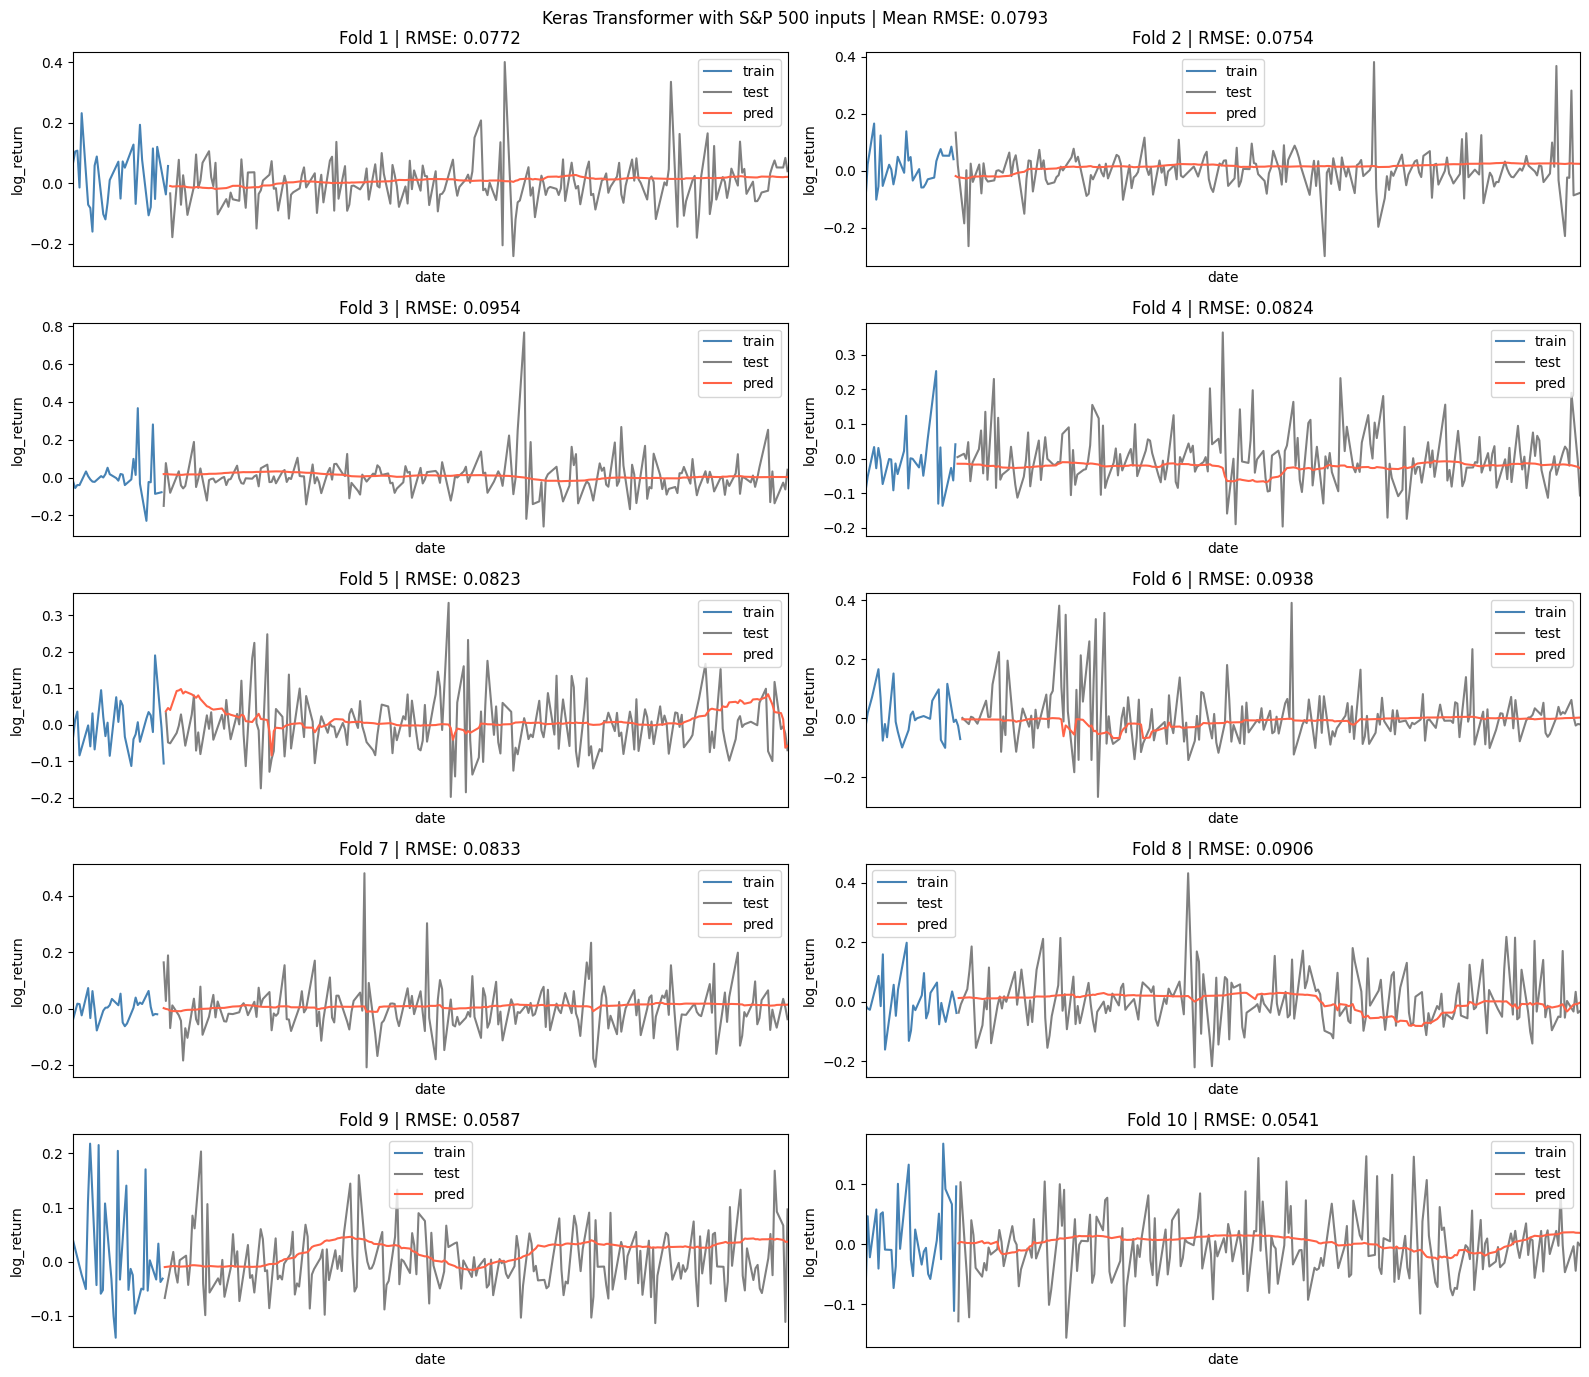

,fold,model,epochs,rmse,mae,r2,directional_accuracy
0,1,keras_transformer,12.0,0.077161,0.055728,-0.017308,0.505
1,1,zero_return,NaN,0.076522,0.054432,-0.000542,0.000
2,1,train_mean,NaN,0.076537,0.054472,-0.000937,0.465
3,1,previous_vix_return,NaN,0.114181,0.079502,-1.227637,0.520
4,2,keras_transformer,12.0,0.075395,0.050823,-0.033426,0.480
5,2,zero_return,NaN,0.074190,0.047140,-0.000662,0.005
6,2,train_mean,NaN,0.074248,0.047218,-0.002217,0.480
7,2,previous_vix_return,NaN,0.107465,0.072197,-1.099583,0.485
8,3,keras_transformer,12.0,0.095435,0.061356,-0.010599,0.520
9,3,zero_return,NaN,0.094934,0.059437,-0.000019,0.005


In [22]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
fold_splits = list(tscv.split(model_df))
n_folds = len(fold_splits)
plot_cols = min(2, max(1, n_folds))
plot_rows = int(np.ceil(n_folds / plot_cols))

fold_metrics = []
fold_predictions = []
fold_histories = []
fold_target_summaries = []
fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for fold, (train_idx, test_idx) in enumerate(fold_splits):
    train_arrays, val_arrays, test_arrays, target_scaler, fold_indices = make_arrays_for_fold(train_idx, test_idx)
    x_train, y_train, _, _ = train_arrays
    x_val, y_val, _, _ = val_arrays
    x_test, _, y_test_raw, test_target_indices = test_arrays

    for split_name, indices in [
        ("train", fold_indices["fit_target_indices"]),
        ("validation", fold_indices["val_target_indices"]),
        ("test", fold_indices["test_target_indices"]),
    ]:
        values = model_df.iloc[indices][TARGET_COL].to_numpy(dtype=np.float64)
        fold_target_summaries.append({
            "fold": fold + 1,
            "split": split_name,
            "rows": len(values),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + fold)
    model = build_keras_transformer(input_shape=(LOOKBACK_DAYS, len(FEATURE_COLS)))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    fold_history = pd.DataFrame({
        "fold": fold + 1,
        "epoch": np.arange(1, len(history.history["loss"]) + 1),
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
    })
    fold_histories.append(fold_history)

    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)
    test_metrics, preds = evaluate_predictions(pred_scaled, y_test_raw, test_target_indices, target_scaler)
    preds["fold"] = fold + 1
    fold_predictions.append(preds)
    fold_metrics.append({"fold": fold + 1, "model": "keras_transformer", "epochs": len(history.history["loss"]), **test_metrics})

    train_target_values = model_df.iloc[fold_indices["fit_target_indices"]][TARGET_COL].to_numpy(dtype=np.float64)
    baseline_predictions = {
        "zero_return": np.zeros_like(y_test_raw, dtype=np.float64),
        "train_mean": np.full_like(y_test_raw, train_target_values.mean(), dtype=np.float64),
        "previous_vix_return": model_df.iloc[test_target_indices]["vix_log_return_lag1"].to_numpy(dtype=np.float64),
    }
    for baseline_name, baseline_pred in baseline_predictions.items():
        fold_metrics.append({
            "fold": fold + 1,
            "model": baseline_name,
            "epochs": np.nan,
            **regression_metrics(y_test_raw, baseline_pred),
        })

    ax = axes[fold]
    train_show_idx = train_idx[-30:]
    sns.lineplot(
        x=model_df["date"].iloc[train_show_idx],
        y=model_df[TARGET_COL].iloc[train_show_idx],
        label="train",
        color="steelblue",
        ax=ax,
    )
    sns.lineplot(x=preds["date"], y=preds["actual"], label="test", color="grey", ax=ax)
    sns.lineplot(x=preds["date"], y=preds["predicted"], label="pred", color="tomato", ax=ax)
    ax.set_xlim([model_df["date"].iloc[train_show_idx[0]], preds["date"].iloc[-1]])
    ax.set_xticks([])
    ax.set_title(f"Fold {fold + 1} | RMSE: {test_metrics['rmse']:.4f}")
    ax.legend()

for ax in axes[n_folds:]:
    ax.set_visible(False)

metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.concat(fold_predictions, ignore_index=True)
history_df = pd.concat(fold_histories, ignore_index=True)
target_summary_df = pd.DataFrame(fold_target_summaries)
mean_transformer_rmse = metrics_df.loc[metrics_df["model"].eq("keras_transformer"), "rmse"].mean()

plt.suptitle(f"Keras Transformer with S&P 500 inputs | Mean RMSE: {mean_transformer_rmse:.4f}")
plt.tight_layout()
plt.show()

metrics_df

## Transformer Direction Classifier

This trains a second Transformer on the same leakage-safe sequence windows, but treats the target as a binary direction label: `prob_vix_rise = P(log_return > 0)` and `prob_vix_fall = 1 - prob_vix_rise`.


Epoch 1/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.4818 - auc: 0.4638 - loss: 0.7654 - val_accuracy: 0.5000 - val_auc: 0.5243 - val_loss: 0.6996
Epoch 2/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5611 - auc: 0.5535 - loss: 0.7023 - val_accuracy: 0.5200 - val_auc: 0.5099 - val_loss: 0.7055
Epoch 3/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5743 - auc: 0.5759 - loss: 0.6831 - val_accuracy: 0.5100 - val_auc: 0.5223 - val_loss: 0.6968
Epoch 4/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5611 - auc: 0.5894 - loss: 0.6810 - val_accuracy: 0.5100 - val_auc: 0.5303 - val_loss: 0.6957
Epoch 5/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5512 - auc: 0.5891 - loss: 0.6822 - val_accuracy: 0.5150 - val_auc: 0.5302 - val_loss: 0.7012
Epoch 6/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5941 - auc: 0.6090 - loss: 0.6741 - val_accuracy: 0.5150 - val_auc: 0.5217 - val_loss: 0.7020
Epoch 7/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40m

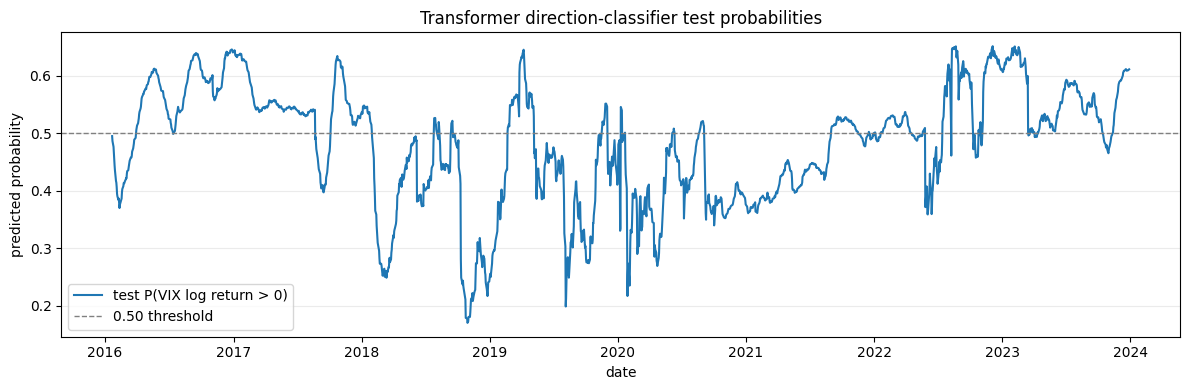

,fold,split,model,epochs,accuracy,precision_rise,recall_rise,f1_rise,actual_rise_rate,predicted_rise_rate,balanced_accuracy,auc
0,1,validation,keras_transformer_direction_classifier,14,0.510,0.493590,0.802083,0.611111,0.480,0.780,0.521234,0.529647
1,1,test,keras_transformer_direction_classifier,14,0.525,0.493421,0.806452,0.612245,0.465,0.760,0.543413,0.590594
2,2,validation,keras_transformer_direction_classifier,11,0.495,0.476190,0.860215,0.613027,0.465,0.840,0.518893,0.560145
3,2,test,keras_transformer_direction_classifier,11,0.480,0.480000,1.000000,0.648649,0.480,1.000,0.500000,0.530649
4,3,validation,keras_transformer_direction_classifier,14,0.490,0.482353,0.854167,0.616541,0.480,0.850,0.504006,0.527244
5,3,test,keras_transformer_direction_classifier,14,0.625,0.587500,0.528090,0.556213,0.445,0.400,0.615396,0.621014
6,4,validation,keras_transformer_direction_classifier,18,0.635,0.590909,0.584270,0.587571,0.445,0.440,0.629973,0.652495
7,4,test,keras_transformer_direction_classifier,18,0.560,0.513514,0.213483,0.301587,0.445,0.185,0.525660,0.536390
8,5,validation,keras_transformer_direction_classifier,22,0.555,0.500000,0.224719,0.310078,0.445,0.200,0.522269,0.611094
9,5,test,keras_transformer_direction_classifier,22,0.550,0.512821,0.219780,0.307692,0.455,0.195,0.522734,0.550459


In [45]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score

CLASSIFIER_THRESHOLD = 0.50


def build_keras_transformer_classifier(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = NumericTokenAndPositionEmbedding(
        sequence_length=input_shape[0],
        model_dim=MODEL_DIM,
        name="classifier_token_position_embedding",
    )(inputs)

    for block_idx in range(NUM_TRANSFORMER_BLOCKS):
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=MODEL_DIM // NUM_HEADS,
            dropout=DROPOUT,
            name=f"classifier_self_attention_{block_idx + 1}",
        )(x, x)
        attention_output = layers.Dropout(DROPOUT)(attention_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn_output = layers.Dense(FF_DIM, activation="gelu")(x)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        ffn_output = layers.Dense(MODEL_DIM)(ffn_output)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D(name="classifier_sequence_pooling")(x)
    x = layers.Dense(MODEL_DIM // 2, activation="gelu")(x)
    x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy", threshold=CLASSIFIER_THRESHOLD),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def direction_labels(target_indices):
    returns = model_df.iloc[target_indices][TARGET_COL].to_numpy(dtype=np.float32)
    return (returns > 0).astype(np.float32)


def direction_metrics(actual_rise, prob_rise, threshold=CLASSIFIER_THRESHOLD):
    actual_rise = np.asarray(actual_rise, dtype=int)
    prob_rise = np.asarray(prob_rise, dtype=np.float64)
    predicted_rise = (prob_rise >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        actual_rise,
        predicted_rise,
        average="binary",
        zero_division=0,
    )
    metrics = {
        "accuracy": float(accuracy_score(actual_rise, predicted_rise)),
        "precision_rise": float(precision),
        "recall_rise": float(recall),
        "f1_rise": float(f1),
        "actual_rise_rate": float(actual_rise.mean()),
        "predicted_rise_rate": float(predicted_rise.mean()),
    }
    if len(np.unique(actual_rise)) > 1:
        metrics["balanced_accuracy"] = float(balanced_accuracy_score(actual_rise, predicted_rise))
        metrics["auc"] = float(roc_auc_score(actual_rise, prob_rise))
    else:
        metrics["balanced_accuracy"] = np.nan
        metrics["auc"] = np.nan
    return metrics


def make_classifier_prediction_frame(target_indices, actual_log_returns, actual_rise, prob_rise, fold, split):
    out = pd.DataFrame({
        "target_index": target_indices,
        "date": model_df.iloc[target_indices]["date"].to_numpy(),
        "actual_log_return": actual_log_returns,
        "actual_vix_rise": actual_rise.astype(int),
        "prob_vix_rise": prob_rise,
        "prob_vix_fall": 1 - prob_rise,
        "predicted_vix_rise": (prob_rise >= CLASSIFIER_THRESHOLD).astype(int),
        "fold": fold,
        "split": split,
    })
    out["actual_direction"] = np.where(out["actual_vix_rise"].eq(1), "rise", "fall")
    out["predicted_direction"] = np.where(out["predicted_vix_rise"].eq(1), "rise", "fall")
    return out


if "fold_splits" not in globals():
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    fold_splits = list(tscv.split(model_df))

classifier_metrics = []
classifier_predictions = []
classifier_validation_predictions = []
classifier_histories = []

for fold, (train_idx, test_idx) in enumerate(fold_splits):
    train_arrays, val_arrays, test_arrays, _, fold_indices = make_arrays_for_fold(train_idx, test_idx)
    x_train, _, _, _ = train_arrays
    x_val, _, y_val_raw, val_target_indices = val_arrays
    x_test, _, y_test_raw, test_target_indices = test_arrays

    y_train_cls = direction_labels(fold_indices["fit_target_indices"])
    y_val_cls = direction_labels(val_target_indices)
    y_test_cls = direction_labels(test_target_indices)

    positive_rate = float(y_train_cls.mean())
    class_weight = None
    if 0 < positive_rate < 1:
        class_weight = {
            0: 0.5 / (1 - positive_rate),
            1: 0.5 / positive_rate,
        }

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + 10_000 + fold)
    classifier = build_keras_transformer_classifier(input_shape=(LOOKBACK_DAYS, len(FEATURE_COLS)))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    history = classifier.fit(
        x_train,
        y_train_cls,
        validation_data=(x_val, y_val_cls),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
        shuffle=True,
    )
    classifier_histories.append(pd.DataFrame({
        "fold": fold + 1,
        "epoch": np.arange(1, len(history.history["loss"]) + 1),
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "train_accuracy": history.history.get("accuracy", [np.nan] * len(history.history["loss"])),
        "val_accuracy": history.history.get("val_accuracy", [np.nan] * len(history.history["loss"])),
        "train_auc": history.history.get("auc", [np.nan] * len(history.history["loss"])),
        "val_auc": history.history.get("val_auc", [np.nan] * len(history.history["loss"])),
    }))

    prob_val_rise = classifier.predict(x_val, verbose=0).reshape(-1)
    val_predictions = make_classifier_prediction_frame(
        val_target_indices,
        y_val_raw,
        y_val_cls,
        prob_val_rise,
        fold + 1,
        "validation",
    )
    classifier_validation_predictions.append(val_predictions)

    prob_test_rise = classifier.predict(x_test, verbose=0).reshape(-1)
    test_predictions = make_classifier_prediction_frame(
        test_target_indices,
        y_test_raw,
        y_test_cls,
        prob_test_rise,
        fold + 1,
        "test",
    )
    classifier_predictions.append(test_predictions)

    classifier_metrics.append({
        "fold": fold + 1,
        "split": "validation",
        "model": "keras_transformer_direction_classifier",
        "epochs": len(history.history["loss"]),
        **direction_metrics(y_val_cls, prob_val_rise),
    })
    classifier_metrics.append({
        "fold": fold + 1,
        "split": "test",
        "model": "keras_transformer_direction_classifier",
        "epochs": len(history.history["loss"]),
        **direction_metrics(y_test_cls, prob_test_rise),
    })

classifier_predictions_df = pd.concat(classifier_predictions, ignore_index=True)
classifier_validation_predictions_df = pd.concat(classifier_validation_predictions, ignore_index=True)
classifier_probability_df = pd.concat(
    [classifier_validation_predictions_df, classifier_predictions_df],
    ignore_index=True,
)
classifier_metrics_df = pd.DataFrame(classifier_metrics)
classifier_history_df = pd.concat(classifier_histories, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=classifier_predictions_df, x="date", y="prob_vix_rise", label="test P(VIX log return > 0)", ax=ax)
ax.axhline(CLASSIFIER_THRESHOLD, color="grey", linestyle="--", linewidth=1, label="0.50 threshold")
ax.set_title("Transformer direction-classifier test probabilities")
ax.set_xlabel("date")
ax.set_ylabel("predicted probability")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

classifier_metrics_df


## Intraday Backtesting

These tests use the VIX direction classifier as an S&P 500 timing signal. When the model predicts a VIX fall, the strategy buys S&P 500 exposure at the open and exits at the close. When the model predicts a VIX rise, it shorts S&P 500 exposure at the open and covers at the close. The backtest runs this on both `^GSPC` as an index proxy and `VOO` as a more realistic ETF proxy.

Strategy 2 uses linearly scaled exposure on the single `prob_vix_rise` axis. The long S&P position is 0 at `BUY_DOWN_THRESHOLD` and scales up to +1 when `prob_vix_rise = 0`, meaning the classifier is 100% confident VIX will fall. The short S&P position is 0 at `SELL_RISE_THRESHOLD` and scales down to -1 when `prob_vix_rise = 1`. Values between the two thresholds stay flat.


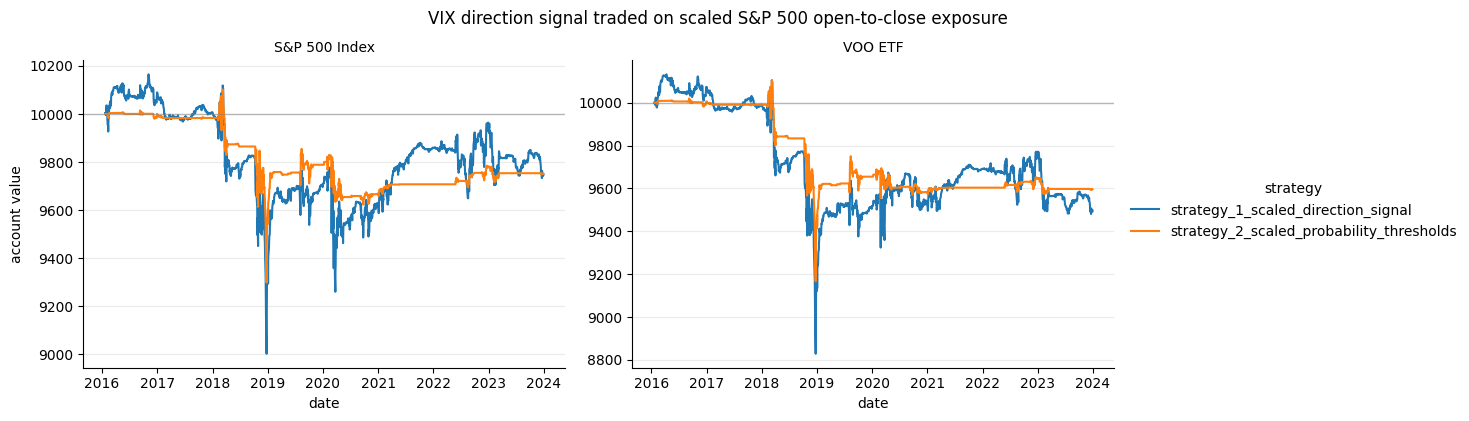

,asset_symbol,asset_label,strategy,days,traded_days,average_abs_exposure,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate,mean_trade_return
0,^GSPC,S&P 500 Index,strategy_1_scaled_direction_signal,2000,2000,0.16404,-0.025051,-0.003192,0.035731,-0.071609,-0.114432,0.513500,-0.000010
1,^GSPC,S&P 500 Index,strategy_2_scaled_probability_thresholds,2000,702,0.04422,-0.024903,-0.003172,0.020261,-0.146704,-0.079533,0.519943,-0.000034
2,VOO,VOO ETF,strategy_1_scaled_direction_signal,2000,2000,0.16404,-0.050276,-0.006479,0.033814,-0.175315,-0.128665,0.508500,-0.000024
3,VOO,VOO ETF,strategy_2_scaled_probability_thresholds,2000,702,0.04422,-0.040409,-0.005184,0.019835,-0.252116,-0.092849,0.508547,-0.000057


,asset_symbol,asset_label,date,asset_open,asset_close,prob_vix_fall,prob_vix_rise,strategy_1_position,strategy_2_position,asset_open_to_close_simple_return,strategy_1_scaled_direction_signal_simple_return,strategy_2_scaled_probability_thresholds_simple_return
0,^GSPC,S&P 500 Index,2016-01-21,1861.459961,1868.989990,0.505171,0.494829,0.010341,0.0,0.004045,0.000042,0.0
1,^GSPC,S&P 500 Index,2016-01-22,1877.400024,1906.900024,0.513828,0.486172,0.027655,0.0,0.015713,0.000435,0.0
2,^GSPC,S&P 500 Index,2016-01-25,1906.280029,1877.079956,0.523856,0.476144,0.047713,0.0,-0.015318,-0.000731,-0.0
3,^GSPC,S&P 500 Index,2016-01-26,1878.790039,1903.630005,0.535282,0.464718,0.070564,0.0,0.013221,0.000933,0.0
4,^GSPC,S&P 500 Index,2016-01-27,1902.520020,1882.949951,0.543877,0.456123,0.087754,0.0,-0.010286,-0.000903,-0.0


In [46]:
BUY_DOWN_THRESHOLD = 0.40
SELL_RISE_THRESHOLD = 0.60
ROUND_TRIP_COST_BPS = 0.0
STARTING_ACCOUNT_VALUE = 10_000.0
POSITION_EPSILON = 1e-12
BACKTEST_ASSETS = {
    "sp500_index": {"symbol": "^GSPC", "label": "S&P 500 Index"},
    "voo_etf": {"symbol": "VOO", "label": "VOO ETF"},
}


def load_market_ohlc_for_backtest(symbol, start=None, end=None):
    start = start or str(model_df["date"].min().date())
    end_date = model_df["date"].max() + pd.Timedelta(days=7)
    end = end or str(end_date.date())

    if yq is not None:
        hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
    elif yf is not None:
        hist = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    else:
        raise ImportError("Install yahooquery or yfinance to download open/close data for backtesting.")

    hist = flatten_yahoo_columns(hist)
    hist["date"] = pd.to_datetime(hist["date"])
    if "close" not in hist.columns and "adjclose" in hist.columns:
        hist["close"] = hist["adjclose"]

    required_cols = {"date", "open", "close"}
    missing_cols = sorted(required_cols.difference(hist.columns))
    if missing_cols:
        raise ValueError(f"{symbol} OHLC data is missing required columns: {missing_cols}")

    return (
        hist[["date", "open", "close"]]
        .rename(columns={"open": "asset_open", "close": "asset_close"})
        .dropna()
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
    )


def scaled_threshold_positions(prob_vix_rise, buy_down_threshold, sell_rise_threshold):
    if buy_down_threshold > sell_rise_threshold:
        raise ValueError("BUY_DOWN_THRESHOLD must be less than or equal to SELL_RISE_THRESHOLD.")

    prob_vix_rise = np.asarray(prob_vix_rise, dtype=np.float64)
    positions = np.zeros_like(prob_vix_rise)

    buy_mask = prob_vix_rise <= buy_down_threshold
    if buy_down_threshold <= POSITION_EPSILON:
        positions[buy_mask] = 1.0
    else:
        positions[buy_mask] = (buy_down_threshold - prob_vix_rise[buy_mask]) / buy_down_threshold

    sell_mask = prob_vix_rise >= sell_rise_threshold
    short_scale = 1 - sell_rise_threshold
    if short_scale <= POSITION_EPSILON:
        positions[sell_mask] = -1.0
    else:
        positions[sell_mask] = -(prob_vix_rise[sell_mask] - sell_rise_threshold) / short_scale

    return np.clip(positions, -1.0, 1.0)


def max_drawdown(equity_curve):
    equity_curve = np.asarray(equity_curve, dtype=np.float64)
    running_peak = np.maximum.accumulate(equity_curve)
    drawdowns = equity_curve / running_peak - 1
    return float(drawdowns.min())


def strategy_sharpe_from_simple_returns(strategy_simple_returns):
    strategy_simple_returns = np.asarray(strategy_simple_returns, dtype=np.float64)
    if len(strategy_simple_returns) < 2:
        return np.nan
    volatility = strategy_simple_returns.std(ddof=1)
    if not np.isfinite(volatility) or volatility <= POSITION_EPSILON:
        return np.nan
    return float(strategy_simple_returns.mean() / volatility * np.sqrt(252))


def apply_strategy_returns(frame, strategy_name, position_col):
    simple_return_col = f"{strategy_name}_simple_return"
    log_return_col = f"{strategy_name}_log_return"
    equity_col = f"{strategy_name}_equity"
    account_value_col = f"{strategy_name}_account_value"

    position = frame[position_col].to_numpy(dtype=np.float64)
    strategy_simple_return = (
        position * frame["asset_open_to_close_simple_return"].to_numpy(dtype=np.float64)
        - np.abs(position) * (ROUND_TRIP_COST_BPS / 10_000)
    )
    if np.any(strategy_simple_return <= -1):
        raise ValueError(f"{strategy_name} produced a return <= -100%; reduce leverage or inspect the data.")

    frame[simple_return_col] = strategy_simple_return
    frame[log_return_col] = np.log1p(strategy_simple_return)
    frame[equity_col] = np.cumprod(1 + strategy_simple_return)
    frame[account_value_col] = STARTING_ACCOUNT_VALUE * frame[equity_col]
    return simple_return_col, log_return_col, equity_col, account_value_col


def summarize_backtest(frame, asset_symbol, asset_label, strategy_name, position_col, simple_return_col, equity_col):
    daily_simple_returns = frame[simple_return_col].to_numpy(dtype=np.float64)
    traded = frame[position_col].abs().gt(POSITION_EPSILON)
    trade_returns = frame.loc[traded, simple_return_col].to_numpy(dtype=np.float64)
    ending_equity = float(frame[equity_col].iloc[-1])
    daily_std = daily_simple_returns.std(ddof=1)
    return {
        "asset_symbol": asset_symbol,
        "asset_label": asset_label,
        "strategy": strategy_name,
        "days": int(len(frame)),
        "traded_days": int(traded.sum()),
        "average_abs_exposure": float(frame[position_col].abs().mean()),
        "cumulative_return": ending_equity - 1,
        "annualized_return": float(ending_equity ** (252 / len(frame)) - 1),
        "annualized_volatility": float(daily_std * np.sqrt(252)),
        "sharpe": strategy_sharpe_from_simple_returns(daily_simple_returns),
        "max_drawdown": max_drawdown(frame[equity_col]),
        "hit_rate": float(np.mean(trade_returns > 0)) if len(trade_returns) else np.nan,
        "mean_trade_return": float(trade_returns.mean()) if len(trade_returns) else np.nan,
    }


if "classifier_predictions_df" not in globals():
    raise RuntimeError("Run the direction-classifier cell first so classifier_predictions_df is available.")

strategy_specs = [
    ("strategy_1_scaled_direction_signal", "strategy_1_position"),
    ("strategy_2_scaled_probability_thresholds", "strategy_2_position"),
]

backtest_frames = []
backtest_summaries = []

for asset_key, asset_info in BACKTEST_ASSETS.items():
    asset_symbol = asset_info["symbol"]
    asset_label = asset_info["label"]
    asset_ohlc = load_market_ohlc_for_backtest(asset_symbol)
    asset_backtest_df = (
        classifier_predictions_df
        .merge(asset_ohlc, on="date", how="left")
        .sort_values("date")
        .reset_index(drop=True)
    )

    missing_ohlc = asset_backtest_df[["asset_open", "asset_close"]].isna().any(axis=1)
    if missing_ohlc.any():
        missing_count = int(missing_ohlc.sum())
        missing_dates = asset_backtest_df.loc[missing_ohlc, "date"].dt.date.astype(str).head(10).tolist()
        print(f"Warning: dropping {missing_count} {asset_symbol} rows with missing open/close data, including {missing_dates}")
        asset_backtest_df = asset_backtest_df.loc[~missing_ohlc].reset_index(drop=True)
    if asset_backtest_df.empty:
        raise ValueError(f"No usable OHLC rows were available for {asset_symbol}.")

    asset_backtest_df["asset_key"] = asset_key
    asset_backtest_df["asset_symbol"] = asset_symbol
    asset_backtest_df["asset_label"] = asset_label
    asset_backtest_df["asset_open_to_close_simple_return"] = (
        asset_backtest_df["asset_close"] / asset_backtest_df["asset_open"] - 1
    )
    asset_backtest_df["asset_open_to_close_log_return"] = np.log1p(
        asset_backtest_df["asset_open_to_close_simple_return"]
    )

    # Strategy 1: scaled long/short S&P exposure around the classifier's 0.50 direction cutoff.
    asset_backtest_df["strategy_1_position"] = scaled_threshold_positions(
        asset_backtest_df["prob_vix_rise"],
        buy_down_threshold=CLASSIFIER_THRESHOLD,
        sell_rise_threshold=CLASSIFIER_THRESHOLD,
    )

    # Strategy 2: scaled long below the lower P(VIX rise) threshold; scaled short above the upper threshold.
    asset_backtest_df["strategy_2_position"] = scaled_threshold_positions(
        asset_backtest_df["prob_vix_rise"],
        buy_down_threshold=BUY_DOWN_THRESHOLD,
        sell_rise_threshold=SELL_RISE_THRESHOLD,
    )

    for strategy_name, position_col in strategy_specs:
        simple_return_col, _, equity_col, _ = apply_strategy_returns(
            asset_backtest_df,
            strategy_name,
            position_col,
        )
        backtest_summaries.append(
            summarize_backtest(
                asset_backtest_df,
                asset_symbol,
                asset_label,
                strategy_name,
                position_col,
                simple_return_col,
                equity_col,
            )
        )

    backtest_frames.append(asset_backtest_df)

backtest_df = pd.concat(backtest_frames, ignore_index=True)
backtest_summary_df = pd.DataFrame(backtest_summaries)

account_value_plot_frames = []
for strategy_name, _ in strategy_specs:
    account_value_col = f"{strategy_name}_account_value"
    strategy_plot_df = backtest_df[
        ["date", "asset_label", "asset_symbol", account_value_col]
    ].rename(columns={account_value_col: "account_value"})
    strategy_plot_df["strategy"] = strategy_name
    account_value_plot_frames.append(strategy_plot_df)

account_value_plot_df = pd.concat(account_value_plot_frames, ignore_index=True)

g = sns.relplot(
    data=account_value_plot_df,
    x="date",
    y="account_value",
    hue="strategy",
    col="asset_label",
    kind="line",
    height=4,
    aspect=1.45,
    facet_kws={"sharey": False},
)
for ax in g.axes.flat:
    ax.axhline(STARTING_ACCOUNT_VALUE, color="grey", linewidth=1, alpha=0.5)
    ax.grid(True, axis="y", alpha=0.25)
g.set_axis_labels("date", "account value")
g.set_titles("{col_name}")
g.fig.suptitle("VIX direction signal traded on scaled S&P 500 open-to-close exposure", y=1.04)
plt.show()

display(backtest_summary_df)

backtest_df[
    [
        "asset_symbol",
        "asset_label",
        "date",
        "asset_open",
        "asset_close",
        "prob_vix_fall",
        "prob_vix_rise",
        "strategy_1_position",
        "strategy_2_position",
        "asset_open_to_close_simple_return",
        "strategy_1_scaled_direction_signal_simple_return",
        "strategy_2_scaled_probability_thresholds_simple_return",
    ]
].head()


## Leakage-Safe Optuna Threshold Tuning

This tunes Strategy 2 thresholds without using the same rows that are backtested. For each fold and each traded asset, Optuna maximizes Sharpe ratio on that fold's earlier validation-period classifier probabilities, assuming a zero risk-free rate, then applies the selected thresholds to the later test-period backtest rows.

The optimized Strategy 2 uses linearly scaled exposure on the single `prob_vix_rise` axis. The long S&P position is 0 at the buy threshold and scales up to +1 when `prob_vix_rise = 0`; the short S&P position is 0 at the sell threshold and scales down to -1 when `prob_vix_rise = 1`. Optuna still samples `BUY_DOWN_THRESHOLD <= SELL_RISE_THRESHOLD`, so the flat zone never crosses.


[I 2026-06-02 17:47:17,498] A new study created in memory with name: no-name-085a7b73-ad53-40e5-9a78-215c3ca336db
[I 2026-06-02 17:47:17,500] Trial 0 finished with value: -1000000000.0 and parameters: {'buy_down_threshold': 0.11505456638977896, 'sell_rise_threshold': 0.6540452190899364}. Best is trial 0 with value: -1000000000.0.
[I 2026-06-02 17:47:17,503] Trial 1 finished with value: 1.5444462021963323 and parameters: {'buy_down_threshold': 0.13339096418598828, 'sell_rise_threshold': 0.34188810277101866}. Best is trial 1 with value: 1.5444462021963323.
[I 2026-06-02 17:47:17,506] Trial 2 finished with value: 1.2228164267061747 and parameters: {'buy_down_threshold': 0.3271390558111398, 'sell_rise_threshold': 0.9052191191588616}. Best is trial 1 with value: 1.5444462021963323.
[I 2026-06-02 17:47:17,508] Trial 3 finished with value: -0.010518878833050343 and parameters: {'buy_down_threshold': 0.6660902130980257, 'sell_rise_threshold': 0.846789572080978}. Best is trial 1 with value: 1.5

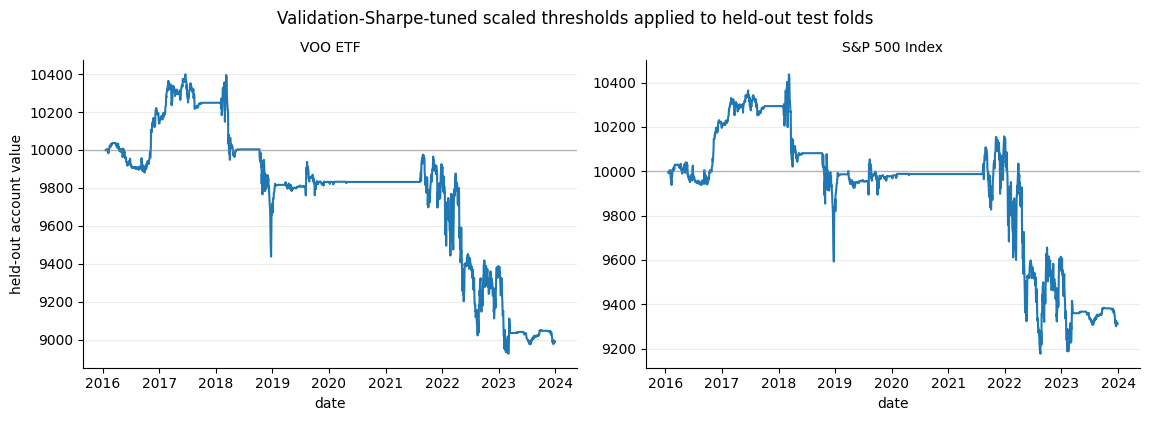

,asset_symbol,asset_label,final_account_value,cumulative_return,traded_days,average_abs_exposure,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate
0,VOO,VOO ETF,8991.118621,-0.100888,1306,0.188357,-0.013310,0.039304,-0.321274,-0.141547,0.501531
1,^GSPC,S&P 500 Index,9313.915373,-0.068608,1313,0.173802,-0.008916,0.039288,-0.208299,-0.120818,0.502666


,asset_symbol,asset_label,fold,tuning_start,tuning_end,test_start,test_end,buy_down_threshold,sell_rise_threshold,threshold_gap,tuning_sharpe,tuning_final_account_value,test_fold_final_account_value,test_fold_cumulative_return,test_traded_days,test_average_abs_exposure,test_sharpe,test_annualized_volatility,test_hit_rate
0,^GSPC,S&P 500 Index,1,2015-04-07,2016-01-20,2016-01-21,2016-11-02,0.451430,0.463769,0.012339,1.905261,10462.118569,10058.036009,0.005804,194,0.175405,0.380478,0.019670,0.510309
1,^GSPC,S&P 500 Index,2,2016-01-21,2016-11-02,2016-11-03,2017-08-21,0.785721,0.849447,0.063726,1.413091,10426.413337,10196.746337,0.019675,200,0.275218,1.421440,0.017377,0.520000
2,^GSPC,S&P 500 Index,3,2016-11-03,2017-08-21,2017-08-22,2018-06-07,0.504438,0.946567,0.442129,1.889171,10017.073239,9830.019243,-0.016998,120,0.135945,-0.573120,0.036530,0.533333
3,^GSPC,S&P 500 Index,4,2017-08-22,2018-06-07,2018-06-08,2019-03-26,0.368684,0.725602,0.356919,0.740654,10166.335348,9905.392787,-0.009461,75,0.114328,-0.258411,0.042824,0.506667
4,^GSPC,S&P 500 Index,5,2018-06-08,2019-03-26,2019-03-27,2020-01-09,0.410131,0.439160,0.029028,1.569164,10202.896315,9995.236349,-0.000476,176,0.134288,-0.018183,0.020978,0.505682
5,^GSPC,S&P 500 Index,6,2019-03-27,2020-01-09,2020-01-10,2020-10-23,0.283021,0.945091,0.662070,2.147462,10076.346884,10005.758994,0.000576,10,0.004253,0.337144,0.002159,0.600000
6,^GSPC,S&P 500 Index,7,2020-01-10,2020-10-23,2020-10-26,2021-08-11,0.338807,0.690302,0.351495,1.192959,10011.225930,10000.000000,0.000000,0,0.000000,NaN,0.000000,NaN
7,^GSPC,S&P 500 Index,8,2020-10-26,2021-08-11,2021-08-12,2022-05-26,0.999962,0.999999,0.000037,1.503651,10779.108277,9540.405981,-0.045959,200,0.494827,-0.657497,0.084714,0.505000
8,^GSPC,S&P 500 Index,9,2021-08-12,2022-05-26,2022-05-27,2023-03-15,0.200445,0.343689,0.143244,1.855048,10425.314388,9822.993098,-0.017701,200,0.344470,-0.326622,0.062873,0.510000
9,^GSPC,S&P 500 Index,10,2022-05-27,2023-03-15,2023-03-16,2023-12-29,0.356216,0.518735,0.162519,2.258584,10013.777838,9951.249508,-0.004875,138,0.059288,-0.811605,0.007552,0.413043


,asset_symbol,asset_label,fold,date,prob_vix_rise,optimized_buy_down_threshold,optimized_sell_rise_threshold,optimized_position,optimized_strategy_simple_return,optimized_account_value
0,VOO,VOO ETF,1,2016-01-21,0.494829,0.440561,0.464721,-0.056247,-0.000119,9998.814385
1,VOO,VOO ETF,1,2016-01-22,0.486172,0.440561,0.464721,-0.040074,-0.000145,9997.363827
2,VOO,VOO ETF,1,2016-01-25,0.476144,0.440561,0.464721,-0.021339,0.000249,9999.851287
3,VOO,VOO ETF,1,2016-01-26,0.464718,0.440561,0.464721,0.000000,0.000000,9999.851287
4,VOO,VOO ETF,1,2016-01-27,0.456123,0.440561,0.464721,0.000000,-0.000000,9999.851287


In [47]:
try:
    import optuna
except ImportError as exc:
    raise ImportError("Install optuna to run threshold tuning: pip install optuna") from exc

OPTUNA_N_TRIALS = 300
OPTUNA_TIMEOUT = None
SHARPE_EPSILON = 1e-12
INVALID_SHARPE_SCORE = -1e9


def build_threshold_strategy_path(frame, buy_down_threshold, sell_rise_threshold, account_value_col="optimized_account_value"):
    if buy_down_threshold > sell_rise_threshold:
        raise ValueError("buy_down_threshold must be less than or equal to sell_rise_threshold.")

    out = frame.sort_values("date").copy()
    positions = scaled_threshold_positions(
        out["prob_vix_rise"],
        buy_down_threshold=buy_down_threshold,
        sell_rise_threshold=sell_rise_threshold,
    )
    strategy_simple_returns = (
        positions * out["asset_open_to_close_simple_return"].to_numpy(dtype=np.float64)
        - np.abs(positions) * (ROUND_TRIP_COST_BPS / 10_000)
    )
    if np.any(strategy_simple_returns <= -1):
        return None

    out["optimized_buy_down_threshold"] = buy_down_threshold
    out["optimized_sell_rise_threshold"] = sell_rise_threshold
    out["optimized_position"] = positions
    out["optimized_strategy_simple_return"] = strategy_simple_returns
    out["optimized_strategy_log_return"] = np.log1p(strategy_simple_returns)
    out[account_value_col] = STARTING_ACCOUNT_VALUE * np.cumprod(1 + strategy_simple_returns)
    return out


def strategy_sharpe(strategy_simple_returns):
    strategy_simple_returns = np.asarray(strategy_simple_returns, dtype=np.float64)
    if len(strategy_simple_returns) < 2:
        return np.nan
    volatility = strategy_simple_returns.std(ddof=1)
    if not np.isfinite(volatility) or volatility <= SHARPE_EPSILON:
        return np.nan
    return float(strategy_simple_returns.mean() / volatility * np.sqrt(252))


def threshold_objective_sharpe(frame, buy_down_threshold, sell_rise_threshold):
    path = build_threshold_strategy_path(frame, buy_down_threshold, sell_rise_threshold)
    if path is None:
        return INVALID_SHARPE_SCORE
    sharpe = strategy_sharpe(path["optimized_strategy_simple_return"])
    if not np.isfinite(sharpe):
        return INVALID_SHARPE_SCORE
    return sharpe


def build_asset_probability_backtest_frame(probability_frame, asset_info):
    asset_symbol = asset_info["symbol"]
    asset_label = asset_info["label"]
    asset_ohlc = load_market_ohlc_for_backtest(asset_symbol)
    out = (
        probability_frame
        .merge(asset_ohlc, on="date", how="left")
        .sort_values(["fold", "date"])
        .reset_index(drop=True)
    )
    missing_ohlc = out[["asset_open", "asset_close"]].isna().any(axis=1)
    if missing_ohlc.any():
        missing_count = int(missing_ohlc.sum())
        missing_dates = out.loc[missing_ohlc, "date"].dt.date.astype(str).head(10).tolist()
        print(f"Warning: dropping {missing_count} {asset_symbol} tuning rows with missing open/close data, including {missing_dates}")
        out = out.loc[~missing_ohlc].reset_index(drop=True)
    if out.empty:
        raise ValueError(f"No usable tuning OHLC rows were available for {asset_symbol}.")

    out["asset_symbol"] = asset_symbol
    out["asset_label"] = asset_label
    out["asset_open_to_close_simple_return"] = out["asset_close"] / out["asset_open"] - 1
    out["asset_open_to_close_log_return"] = np.log1p(out["asset_open_to_close_simple_return"])
    return out


if "backtest_df" not in globals():
    raise RuntimeError("Run the S&P 500 backtest cell first so backtest_df is available.")
if "classifier_validation_predictions_df" not in globals():
    raise RuntimeError("Run the updated direction-classifier cell first so validation probabilities are available.")

optuna_studies = {}
optuna_threshold_rows = []
optuna_test_paths = []
validation_backtest_frames = []

for asset_key, asset_info in BACKTEST_ASSETS.items():
    asset_symbol = asset_info["symbol"]
    asset_label = asset_info["label"]
    validation_asset_frame = build_asset_probability_backtest_frame(
        classifier_validation_predictions_df,
        asset_info,
    )
    validation_backtest_frames.append(validation_asset_frame)
    test_asset_frame = (
        backtest_df
        .loc[backtest_df["asset_symbol"].eq(asset_symbol)]
        .sort_values(["fold", "date"])
        .reset_index(drop=True)
    )

    for fold in sorted(test_asset_frame["fold"].unique()):
        tuning_frame = (
            validation_asset_frame
            .loc[validation_asset_frame["fold"].eq(fold)]
            .sort_values("date")
            .reset_index(drop=True)
        )
        test_frame = (
            test_asset_frame
            .loc[test_asset_frame["fold"].eq(fold)]
            .sort_values("date")
            .reset_index(drop=True)
        )
        if tuning_frame.empty or test_frame.empty:
            continue

        def objective(trial):
            buy_down_threshold = trial.suggest_float("buy_down_threshold", 0.0, 1.0)
            sell_rise_threshold = trial.suggest_float("sell_rise_threshold", buy_down_threshold, 1.0)
            validation_sharpe = threshold_objective_sharpe(
                tuning_frame,
                buy_down_threshold,
                sell_rise_threshold,
            )
            trial.set_user_attr("threshold_gap", sell_rise_threshold - buy_down_threshold)
            return validation_sharpe

        sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED + int(fold))
        study = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=False)
        optuna_studies[(asset_symbol, int(fold))] = study

        best_thresholds = study.best_params
        tuning_path = build_threshold_strategy_path(
            tuning_frame,
            best_thresholds["buy_down_threshold"],
            best_thresholds["sell_rise_threshold"],
            account_value_col="tuning_account_value",
        )
        test_path = build_threshold_strategy_path(
            test_frame,
            best_thresholds["buy_down_threshold"],
            best_thresholds["sell_rise_threshold"],
        )
        if tuning_path is None or test_path is None:
            continue

        tuning_sharpe = strategy_sharpe(tuning_path["optimized_strategy_simple_return"])
        test_path["tuned_on_split"] = "validation"
        test_path["tuning_sharpe"] = tuning_sharpe
        test_path["tuning_final_account_value"] = float(tuning_path["tuning_account_value"].iloc[-1])
        optuna_test_paths.append(test_path)

        traded = test_path["optimized_position"].abs().gt(POSITION_EPSILON)
        trade_returns = test_path.loc[traded, "optimized_strategy_simple_return"]
        daily_returns = test_path["optimized_strategy_simple_return"]
        test_sharpe = strategy_sharpe(daily_returns)
        daily_std = daily_returns.std(ddof=1)
        optuna_threshold_rows.append({
            "asset_symbol": asset_symbol,
            "asset_label": asset_label,
            "fold": int(fold),
            "tuning_start": tuning_frame["date"].min(),
            "tuning_end": tuning_frame["date"].max(),
            "test_start": test_frame["date"].min(),
            "test_end": test_frame["date"].max(),
            "buy_down_threshold": best_thresholds["buy_down_threshold"],
            "sell_rise_threshold": best_thresholds["sell_rise_threshold"],
            "threshold_gap": best_thresholds["sell_rise_threshold"] - best_thresholds["buy_down_threshold"],
            "tuning_sharpe": tuning_sharpe,
            "tuning_final_account_value": float(tuning_path["tuning_account_value"].iloc[-1]),
            "test_fold_final_account_value": float(test_path["optimized_account_value"].iloc[-1]),
            "test_fold_cumulative_return": float(test_path["optimized_account_value"].iloc[-1] / STARTING_ACCOUNT_VALUE - 1),
            "test_traded_days": int(traded.sum()),
            "test_average_abs_exposure": float(test_path["optimized_position"].abs().mean()),
            "test_sharpe": test_sharpe,
            "test_annualized_volatility": float(daily_std * np.sqrt(252)),
            "test_hit_rate": float(np.mean(trade_returns > 0)) if len(trade_returns) else np.nan,
        })

validation_backtest_df = pd.concat(validation_backtest_frames, ignore_index=True)
optuna_fold_thresholds_df = pd.DataFrame(optuna_threshold_rows)
optuna_test_backtest_df = pd.concat(optuna_test_paths, ignore_index=True)

# Build the held-out account value by compounding the test returns after applying each fold's validation-Sharpe-tuned thresholds.
optuna_test_backtest_df = optuna_test_backtest_df.sort_values(["asset_symbol", "date"]).reset_index(drop=True)
optuna_test_backtest_df["optimized_account_value"] = (
    STARTING_ACCOUNT_VALUE
    * (1 + optuna_test_backtest_df["optimized_strategy_simple_return"])
    .groupby(optuna_test_backtest_df["asset_symbol"])
    .cumprod()
)

optuna_test_summary_rows = []
for asset_symbol, asset_frame in optuna_test_backtest_df.groupby("asset_symbol", sort=False):
    asset_label = asset_frame["asset_label"].iloc[0]
    traded = asset_frame["optimized_position"].abs().gt(POSITION_EPSILON)
    trade_returns = asset_frame.loc[traded, "optimized_strategy_simple_return"]
    daily_returns = asset_frame["optimized_strategy_simple_return"]
    daily_std = daily_returns.std(ddof=1)
    ending_equity = float(asset_frame["optimized_account_value"].iloc[-1] / STARTING_ACCOUNT_VALUE)
    optuna_test_summary_rows.append({
        "asset_symbol": asset_symbol,
        "asset_label": asset_label,
        "final_account_value": float(asset_frame["optimized_account_value"].iloc[-1]),
        "cumulative_return": ending_equity - 1,
        "traded_days": int(traded.sum()),
        "average_abs_exposure": float(asset_frame["optimized_position"].abs().mean()),
        "annualized_return": float(ending_equity ** (252 / len(asset_frame)) - 1),
        "annualized_volatility": float(daily_std * np.sqrt(252)),
        "sharpe": strategy_sharpe(daily_returns),
        "max_drawdown": max_drawdown(asset_frame["optimized_account_value"]),
        "hit_rate": float(np.mean(trade_returns > 0)) if len(trade_returns) else np.nan,
    })
optuna_test_summary_df = pd.DataFrame(optuna_test_summary_rows)

g = sns.relplot(
    data=optuna_test_backtest_df,
    x="date",
    y="optimized_account_value",
    col="asset_label",
    kind="line",
    height=4,
    aspect=1.45,
    facet_kws={"sharey": False},
)
for ax in g.axes.flat:
    ax.axhline(STARTING_ACCOUNT_VALUE, color="grey", linewidth=1, alpha=0.5)
    ax.grid(True, axis="y", alpha=0.25)
g.set_axis_labels("date", "held-out account value")
g.set_titles("{col_name}")
g.fig.suptitle("Validation-Sharpe-tuned scaled thresholds applied to held-out test folds", y=1.04)
plt.show()

display(optuna_test_summary_df)
display(optuna_fold_thresholds_df)

optuna_test_backtest_df[
    [
        "asset_symbol",
        "asset_label",
        "fold",
        "date",
        "prob_vix_rise",
        "optimized_buy_down_threshold",
        "optimized_sell_rise_threshold",
        "optimized_position",
        "optimized_strategy_simple_return",
        "optimized_account_value",
    ]
].head()


## Inverse Strategy Backtests

This tests the inverse of the scaled VIX-signal strategies: whenever the original strategy is long S&P exposure, the inverse strategy is short by the same amount; whenever the original strategy is short, the inverse strategy is long by the same amount. It includes both the fixed-threshold strategies and the leakage-safe Optuna validation-tuned strategy.


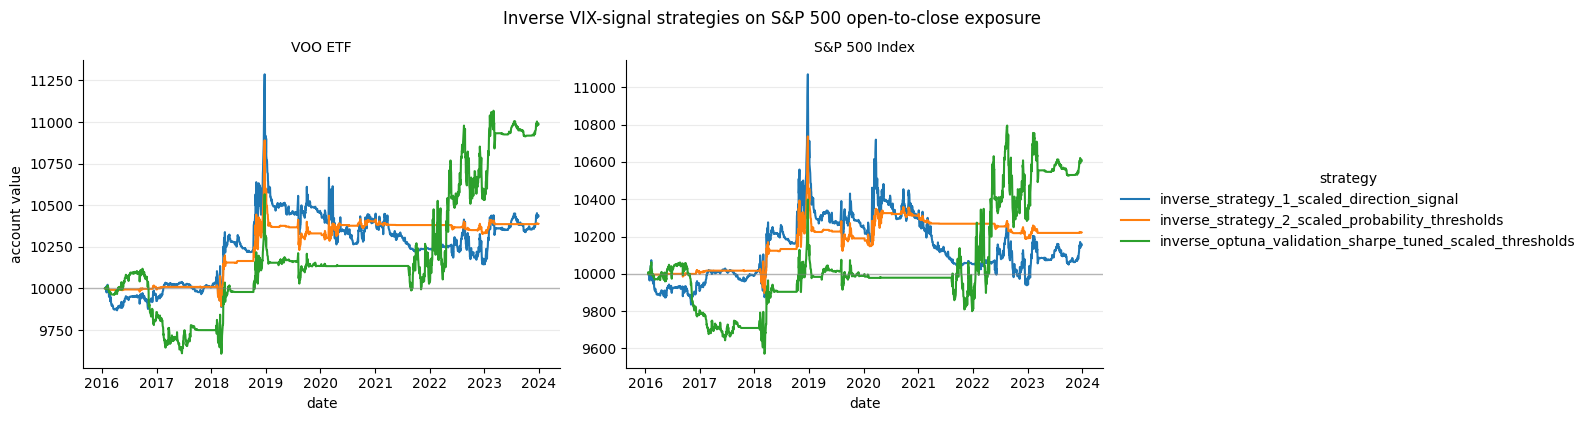

,asset_symbol,asset_label,strategy,days,traded_days,average_abs_exposure,final_account_value,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,hit_rate
0,VOO,VOO ETF,inverse_strategy_1_scaled_direction_signal,2000,2000,0.164040,10434.292201,0.043429,0.005371,0.033814,0.175315,-0.101224,0.487000
1,^GSPC,S&P 500 Index,inverse_strategy_1_scaled_direction_signal,2000,2000,0.164040,10153.591894,0.015359,0.001922,0.035731,0.071609,-0.102277,0.486000
2,VOO,VOO ETF,inverse_strategy_2_scaled_probability_thresholds,2000,702,0.044220,10388.629012,0.038863,0.004816,0.019835,0.252116,-0.060513,0.491453
3,^GSPC,S&P 500 Index,inverse_strategy_2_scaled_probability_thresholds,2000,702,0.044220,10222.038152,0.022204,0.002771,0.020261,0.146704,-0.057215,0.480057
4,VOO,VOO ETF,inverse_optuna_validation_sharpe_tuned_scaled_...,2000,1306,0.188357,10986.567697,0.098657,0.011926,0.039304,0.321274,-0.054705,0.495406
5,^GSPC,S&P 500 Index,inverse_optuna_validation_sharpe_tuned_scaled_...,2000,1313,0.173802,10605.938267,0.060594,0.007440,0.039288,0.208299,-0.057617,0.496573


,asset_symbol,asset_label,fold,date,prob_vix_rise,optimized_position,inverse_optuna_validation_sharpe_tuned_scaled_thresholds_position,inverse_optuna_validation_sharpe_tuned_scaled_thresholds_simple_return,inverse_optuna_validation_sharpe_tuned_scaled_thresholds_account_value
0,VOO,VOO ETF,1,2016-01-21,0.494829,-0.056247,0.056247,0.000119,10001.185615
1,VOO,VOO ETF,1,2016-01-22,0.486172,-0.040074,0.040074,0.000145,10002.636517
2,VOO,VOO ETF,1,2016-01-25,0.476144,-0.021339,0.021339,-0.000249,10000.147745
3,VOO,VOO ETF,1,2016-01-26,0.464718,0.000000,-0.000000,-0.000000,10000.147745
4,VOO,VOO ETF,1,2016-01-27,0.456123,0.000000,-0.000000,0.000000,10000.147745


In [48]:
if "backtest_df" not in globals():
    raise RuntimeError("Run the intraday backtesting cell first so backtest_df is available.")
if "optuna_test_backtest_df" not in globals():
    raise RuntimeError("Run the leakage-safe Optuna threshold tuning cell first so optuna_test_backtest_df is available.")


def add_inverse_strategy_returns(frame, strategy_name, original_position_col, return_col="asset_open_to_close_simple_return"):
    out = frame.copy()
    position_col = f"{strategy_name}_position"
    simple_return_col = f"{strategy_name}_simple_return"
    log_return_col = f"{strategy_name}_log_return"
    account_value_col = f"{strategy_name}_account_value"

    out[position_col] = -out[original_position_col].to_numpy(dtype=np.float64)
    strategy_simple_return = (
        out[position_col].to_numpy(dtype=np.float64) * out[return_col].to_numpy(dtype=np.float64)
        - out[position_col].abs().to_numpy(dtype=np.float64) * (ROUND_TRIP_COST_BPS / 10_000)
    )
    if np.any(strategy_simple_return <= -1):
        raise ValueError(f"{strategy_name} produced a return <= -100%; inspect the data or leverage.")

    out[simple_return_col] = strategy_simple_return
    out[log_return_col] = np.log1p(strategy_simple_return)
    out[account_value_col] = (
        STARTING_ACCOUNT_VALUE
        * (1 + out[simple_return_col])
        .groupby(out["asset_symbol"])
        .cumprod()
    )
    return out, position_col, simple_return_col, account_value_col


def summarize_inverse_strategy(frame, strategy_name, position_col, simple_return_col, account_value_col):
    rows = []
    for asset_symbol, asset_frame in frame.groupby("asset_symbol", sort=False):
        asset_label = asset_frame["asset_label"].iloc[0]
        traded = asset_frame[position_col].abs().gt(POSITION_EPSILON)
        trade_returns = asset_frame.loc[traded, simple_return_col].to_numpy(dtype=np.float64)
        daily_returns = asset_frame[simple_return_col].to_numpy(dtype=np.float64)
        daily_std = daily_returns.std(ddof=1)
        ending_equity = float(asset_frame[account_value_col].iloc[-1] / STARTING_ACCOUNT_VALUE)
        rows.append({
            "asset_symbol": asset_symbol,
            "asset_label": asset_label,
            "strategy": strategy_name,
            "days": int(len(asset_frame)),
            "traded_days": int(traded.sum()),
            "average_abs_exposure": float(asset_frame[position_col].abs().mean()),
            "final_account_value": float(asset_frame[account_value_col].iloc[-1]),
            "cumulative_return": ending_equity - 1,
            "annualized_return": float(ending_equity ** (252 / len(asset_frame)) - 1),
            "annualized_volatility": float(daily_std * np.sqrt(252)),
            "sharpe": strategy_sharpe_from_simple_returns(daily_returns),
            "max_drawdown": max_drawdown(asset_frame[account_value_col]),
            "hit_rate": float(np.mean(trade_returns > 0)) if len(trade_returns) else np.nan,
        })
    return rows


inverse_summary_rows = []
inverse_account_value_plot_frames = []

fixed_inverse_specs = [
    ("inverse_strategy_1_scaled_direction_signal", "strategy_1_position"),
    ("inverse_strategy_2_scaled_probability_thresholds", "strategy_2_position"),
]
for strategy_name, original_position_col in fixed_inverse_specs:
    inverse_frame, position_col, simple_return_col, account_value_col = add_inverse_strategy_returns(
        backtest_df.sort_values(["asset_symbol", "date"]).reset_index(drop=True),
        strategy_name,
        original_position_col,
    )
    inverse_summary_rows.extend(
        summarize_inverse_strategy(inverse_frame, strategy_name, position_col, simple_return_col, account_value_col)
    )
    plot_frame = inverse_frame[["date", "asset_symbol", "asset_label", account_value_col]].rename(
        columns={account_value_col: "account_value"}
    )
    plot_frame["strategy"] = strategy_name
    inverse_account_value_plot_frames.append(plot_frame)

inverse_optuna_backtest_df, inverse_optuna_position_col, inverse_optuna_simple_return_col, inverse_optuna_account_value_col = (
    add_inverse_strategy_returns(
        optuna_test_backtest_df.sort_values(["asset_symbol", "date"]).reset_index(drop=True),
        "inverse_optuna_validation_sharpe_tuned_scaled_thresholds",
        "optimized_position",
    )
)
inverse_summary_rows.extend(
    summarize_inverse_strategy(
        inverse_optuna_backtest_df,
        "inverse_optuna_validation_sharpe_tuned_scaled_thresholds",
        inverse_optuna_position_col,
        inverse_optuna_simple_return_col,
        inverse_optuna_account_value_col,
    )
)
inverse_optuna_plot_frame = inverse_optuna_backtest_df[
    ["date", "asset_symbol", "asset_label", inverse_optuna_account_value_col]
].rename(columns={inverse_optuna_account_value_col: "account_value"})
inverse_optuna_plot_frame["strategy"] = "inverse_optuna_validation_sharpe_tuned_scaled_thresholds"
inverse_account_value_plot_frames.append(inverse_optuna_plot_frame)

inverse_strategy_summary_df = pd.DataFrame(inverse_summary_rows)
inverse_account_value_plot_df = pd.concat(inverse_account_value_plot_frames, ignore_index=True)

g = sns.relplot(
    data=inverse_account_value_plot_df,
    x="date",
    y="account_value",
    hue="strategy",
    col="asset_label",
    kind="line",
    height=4,
    aspect=1.45,
    facet_kws={"sharey": False},
)
for ax in g.axes.flat:
    ax.axhline(STARTING_ACCOUNT_VALUE, color="grey", linewidth=1, alpha=0.5)
    ax.grid(True, axis="y", alpha=0.25)
g.set_axis_labels("date", "account value")
g.set_titles("{col_name}")
g.fig.suptitle("Inverse VIX-signal strategies on S&P 500 open-to-close exposure", y=1.04)
plt.show()

display(inverse_strategy_summary_df)

inverse_optuna_backtest_df[
    [
        "asset_symbol",
        "asset_label",
        "fold",
        "date",
        "prob_vix_rise",
        "optimized_position",
        inverse_optuna_position_col,
        inverse_optuna_simple_return_col,
        inverse_optuna_account_value_col,
    ]
].head()


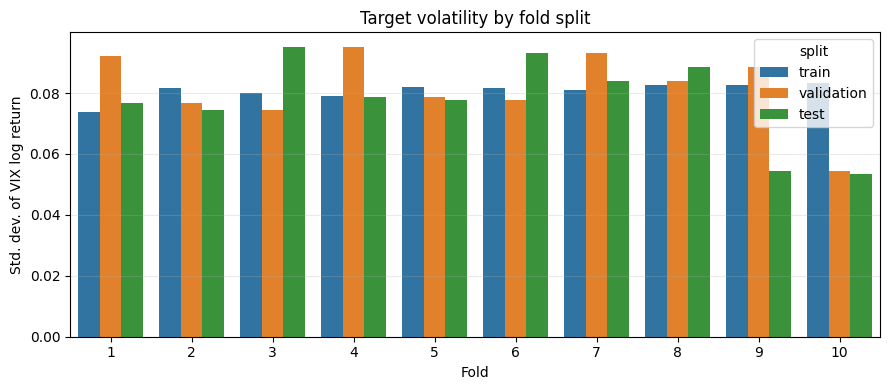

,fold,split,rows,mean,std,min,max
0,1,train,303,0.000560,0.073853,-0.192642,0.279008
1,1,validation,200,0.003134,0.092204,-0.201162,0.381495
2,1,test,200,-0.001782,0.076694,-0.240590,0.401011
3,2,train,503,0.001584,0.081566,-0.201162,0.381495
4,2,validation,200,-0.001782,0.076694,-0.240590,0.401011
5,2,test,200,-0.001908,0.074352,-0.299831,0.381070
6,3,train,703,0.000626,0.080170,-0.240590,0.401011
7,3,validation,200,-0.001908,0.074352,-0.299831,0.381070
8,3,test,200,-0.000419,0.095172,-0.259645,0.768245
9,4,train,903,0.000065,0.078885,-0.299831,0.401011


In [12]:
if "target_summary_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so target_summary_df is available.")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=target_summary_df, x="fold", y="std", hue="split", ax=ax)
ax.set_title("Target volatility by fold split")
ax.set_xlabel("Fold")
ax.set_ylabel("Std. dev. of VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

target_summary_df


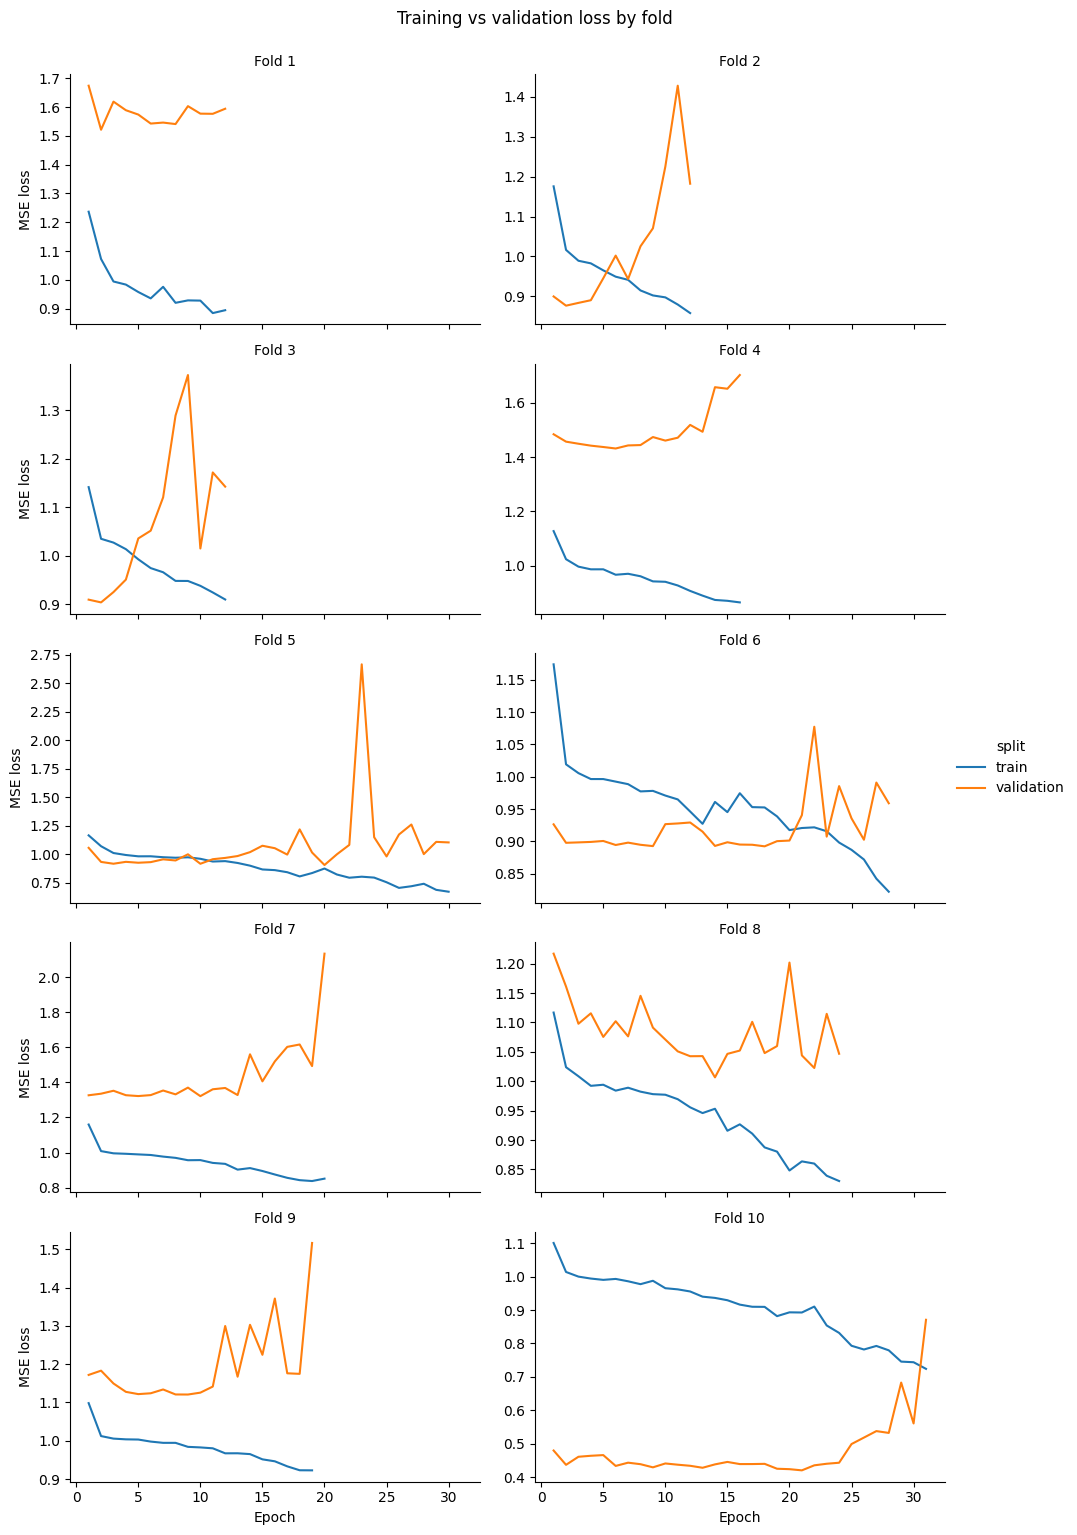

,fold,epoch,train_loss,val_loss
0,1,12,0.894645,1.594346
1,2,12,0.857744,1.182408
2,3,12,0.909778,1.142647
3,4,16,0.863969,1.703008
4,5,30,0.669485,1.101889
5,6,28,0.821925,0.958946
6,7,20,0.851140,2.133655
7,8,24,0.830364,1.046817
8,9,19,0.922698,1.516365
9,10,31,0.724187,0.870822


In [13]:
if "history_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so history_df is available.")

loss_long = history_df.melt(
    id_vars=["fold", "epoch"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
)
loss_long["split"] = loss_long["split"].map({"train_loss": "train", "val_loss": "validation"})
loss_col_wrap = min(2, max(1, history_df["fold"].nunique()))

g = sns.relplot(
    data=loss_long,
    x="epoch",
    y="loss",
    hue="split",
    col="fold",
    col_wrap=loss_col_wrap,
    kind="line",
    height=3,
    aspect=1.6,
    facet_kws={"sharey": False},
)
g.set_titles("Fold {col_name}")
g.set_axis_labels("Epoch", "MSE loss")
g.fig.suptitle("Training vs validation loss by fold", y=1.02)
plt.show()

history_df.groupby("fold").tail(1).reset_index(drop=True)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=predictions_df, x="date", y="actual", label="actual", color="grey", ax=ax)
sns.lineplot(data=predictions_df, x="date", y="predicted", label="predicted", color="tomato", ax=ax)
ax.set_title("Keras Transformer walk-forward log-return predictions")
ax.set_xlabel("date")
ax.set_ylabel("VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

required_price_cols = {"adjclose"}
missing_price_cols = sorted(required_price_cols.difference(model_df.columns))
if missing_price_cols:
    raise ValueError(f"model_df is missing price columns needed for price reconstruction: {missing_price_cols}")

price_predictions_df = (
    predictions_df.copy()
    .sort_values(["target_index", "fold"])
    .drop_duplicates(subset=["target_index"], keep="last")
    .sort_values("target_index")
    .reset_index(drop=True)
)

target_positions = price_predictions_df["target_index"].to_numpy(dtype=int)
previous_target_positions = target_positions - 1
if len(target_positions) == 0:
    raise ValueError("predictions_df is empty; run the walk-forward evaluation cell first.")
if np.any(previous_target_positions < 0):
    raise ValueError("Cannot build price predictions without a prior VIX close for every target row.")

price_predictions_df["date"] = model_df.iloc[target_positions]["date"].to_numpy()
price_predictions_df["actual_vix_price"] = model_df.iloc[target_positions]["adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["previous_actual_vix_price"] = model_df.iloc[previous_target_positions]["adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["actual_simple_return"] = np.expm1(price_predictions_df["actual"])
price_predictions_df["predicted_simple_return"] = np.expm1(price_predictions_df["predicted"])
price_predictions_df["actual_vix_price_from_return"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["actual"])
)
price_predictions_df["predicted_vix_price_one_day"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["predicted"])
)

anchor_index = int(previous_target_positions[0])
anchor_row = model_df.iloc[anchor_index]
anchor_date = anchor_row["date"]
anchor_price = float(anchor_row["adjclose"])

actual_path_prices = []
predicted_path_prices = []
previous_actual_path_price = anchor_price
previous_predicted_path_price = anchor_price
for actual_log_return, predicted_log_return in zip(
    price_predictions_df["actual"].to_numpy(dtype=np.float64),
    price_predictions_df["predicted"].to_numpy(dtype=np.float64),
):
    previous_actual_path_price = previous_actual_path_price * np.exp(actual_log_return)
    previous_predicted_path_price = previous_predicted_path_price * np.exp(predicted_log_return)
    actual_path_prices.append(previous_actual_path_price)
    predicted_path_prices.append(previous_predicted_path_price)

price_predictions_df["actual_vix_price_from_path"] = actual_path_prices
price_predictions_df["predicted_vix_price"] = predicted_path_prices

non_consecutive_targets = price_predictions_df["target_index"].diff().dropna().ne(1)
if non_consecutive_targets.any():
    print(
        "Warning: predicted target rows are not consecutive; "
        "the recursive price path compounds across available predicted rows."
    )

price_plot_df = pd.concat(
    [
        pd.DataFrame(
            {
                "date": [anchor_date],
                "actual_vix_price": [anchor_price],
                "predicted_vix_price": [anchor_price],
            }
        ),
        price_predictions_df[["date", "actual_vix_price", "predicted_vix_price"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
for ax in axes:
    ax.plot(price_plot_df["date"], price_plot_df["actual_vix_price"], label="actual VIX close", color="grey")
    ax.plot(price_plot_df["date"], price_plot_df["predicted_vix_price"], label="predicted VIX close", color="tomato")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()

axes[0].set_yscale("log")
axes[0].set_title("Keras Transformer walk-forward recursive VIX price path")
axes[0].set_ylabel("VIX close (log scale)")

actual_min = price_plot_df["actual_vix_price"].min()
actual_max = price_plot_df["actual_vix_price"].max()
actual_padding = max((actual_max - actual_min) * 0.15, 1.0)
axes[1].set_ylim(max(0, actual_min - actual_padding), actual_max + actual_padding)
axes[1].set_title("Recursive VIX price path, zoomed to actual VIX range")
axes[1].set_xlabel("date")
axes[1].set_ylabel("VIX close")
plt.tight_layout()
plt.show()

model_summary = (
    metrics_df.groupby("model", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        mean_directional_accuracy=("directional_accuracy", "mean"),
    )
    .sort_values("mean_rmse")
)
display(model_summary)

keras_rows = metrics_df[metrics_df["model"].eq("keras_transformer")]
recursive_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price"],
)
one_day_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price_one_day"],
)
one_day_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_return"]
).abs().max()
path_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_path"]
).abs().max()
print(f"Keras Transformer mean log-return RMSE: {keras_rows['rmse'].mean():.4f}")
print(f"Keras Transformer mean log-return MAE: {keras_rows['mae'].mean():.4f}")
print(f"Keras Transformer recursive VIX price RMSE: {recursive_price_metrics['rmse']:.4f}")
print(f"Keras Transformer recursive VIX price MAE: {recursive_price_metrics['mae']:.4f}")
print(f"Keras Transformer one-day anchored VIX price RMSE: {one_day_price_metrics['rmse']:.4f}")
print(f"Keras Transformer one-day anchored VIX price MAE: {one_day_price_metrics['mae']:.4f}")
print(f"Max actual price reconstruction error from one-day log returns: {one_day_reconstruction_error:.8f}")
print(f"Max actual price reconstruction error from cumulative log returns: {path_reconstruction_error:.8f}")
price_predictions_df[
    [
        "date",
        "actual_vix_price",
        "predicted_vix_price",
        "predicted_vix_price_one_day",
        "actual_simple_return",
        "predicted_simple_return",
        "fold",
    ]
].head()